# UNAD - Analisis de Datos

## John Alejandro Ceballos Castaño

### Predicción de Vehicle dataset con Regresión Lineal

### Pasos de la Actividad

1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.
2. Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario
3. Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características
4. Dividir el dataset en Train y Test para evaluar correctamente el modelo
5. Entrenar el modelo configurando los diferentes hiperparámetros
6. Evaluar el desempeño del modelo en el conjunto de Test con métricas como precisión, recall, F1-score, etc
7. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo.
8. Interpretar, analizar y documentar los resultados obtenidos

### 1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.

In [30]:
#Cargar las librerias necesarias

import pandas as pd # Manejo y análisis de estructuras de datos
import numpy as np # Cálculo numérico y el análisis de datos
import seaborn as sns # Creación gráficos estadísticos
import matplotlib.pyplot as plt # Creación de gráficos en dos dimensiones

# librerías de para implementar modelos de ciencia de datos
from sklearn import metrics
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score

In [4]:
# lectura de datos en Python y lo cargamos en la variable Datos

Datos = pd.read_csv('C:/Users/Alejandro/Documents/MEGA/UNAD/Periodo 6/Analisis de Datos/Tarea 3/Vehicle dataset/Car details v4.csv')

In [5]:
#Identificación de Columnas y Filas

Datos.shape

(2059, 20)

In [6]:
# Realizamos lectura de los Datos para el análisis exploratorio

Datos.head(10)

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0
5,Maruti Suzuki,Ciaz ZXi,675000,2017,73315,Petrol,Manual,Pune,Grey,First,Individual,1373 cc,91 bhp @ 6000 rpm,130 Nm @ 4000 rpm,FWD,4490.0,1730.0,1485.0,5.0,43.0
6,Mercedes-Benz,CLA 200 Petrol Sport,1898999,2015,47000,Petrol,Automatic,Mumbai,White,Second,Individual,1991 cc,181 bhp @ 5500 rpm,300 Nm @ 1200 rpm,FWD,4630.0,1777.0,1432.0,5.0,NaN
7,BMW,X1 xDrive20d M Sport,2650000,2017,75000,Diesel,Automatic,Coimbatore,White,Second,Individual,1995 cc,188 bhp @ 4000 rpm,400 Nm @ 1750 rpm,AWD,4439.0,1821.0,1612.0,5.0,51.0
8,Skoda,Octavia 1.8 TSI Style Plus AT [2017],1390000,2017,56000,Petrol,Automatic,Mumbai,White,First,Individual,1798 cc,177 bhp @ 5100 rpm,250 Nm @ 1250 rpm,FWD,4670.0,1814.0,1476.0,5.0,50.0
9,Nissan,Terrano XL (D),575000,2015,85000,Diesel,Manual,Mumbai,White,First,Individual,1461 cc,84 bhp @ 3750 rpm,200 Nm @ 1900 rpm,FWD,4331.0,1822.0,1671.0,5.0,50.0


In [7]:
# Descripción de los datos
Datos.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [8]:
#Identificación de Datos Faltante

Datos.isna().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

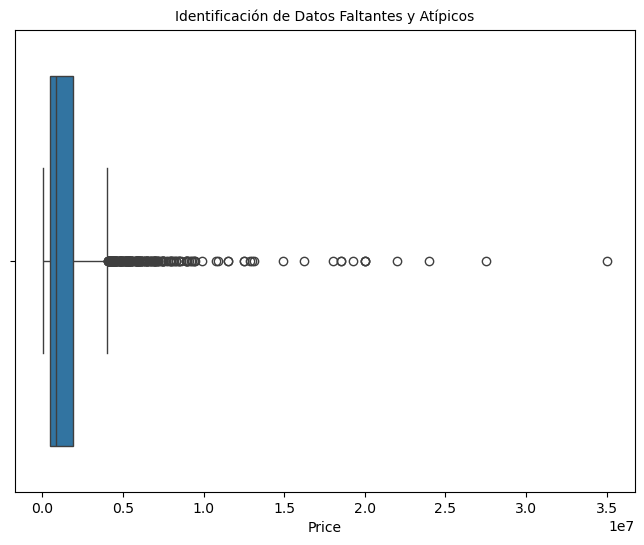

In [9]:
#Identificación de Datos Faltantes y Atípicos

plt.figure(figsize=(8, 6))
sns.boxplot(x=Datos['Price'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

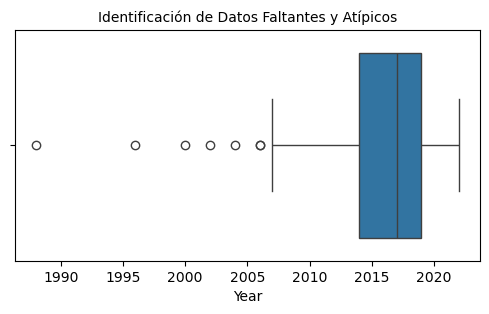

In [10]:
#Identificación de Datos Faltantes y Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['Year'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

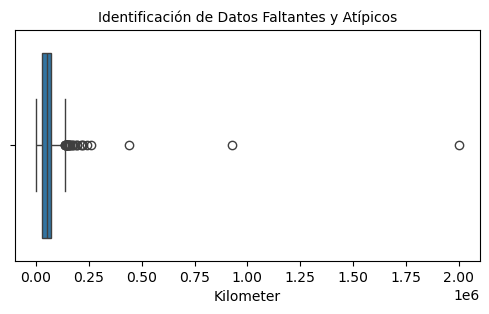

In [11]:
#Identificación de Datos Faltantes y Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['Kilometer'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

### 2. Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario

In [12]:
#Revisión del tipo de datos y datos faltantes

Datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [13]:
nivel_minimo=50
nivel_maximo=4500000
Total_Atipicos=((Datos['Price']<nivel_minimo)|(Datos['Price']>nivel_maximo)).sum()
print("El total de datos atípicos para Price es {}".format(Total_Atipicos))

El total de datos atípicos para Price es 167


In [14]:
nivel_minimo=2007
nivel_maximo=2025
Total_Atipicos=((Datos['Year']<nivel_minimo)|(Datos['Year']>nivel_maximo)).sum()
print("El total de datos atípicos para Price es {}".format(Total_Atipicos))

El total de datos atípicos para Price es 7


In [15]:
nivel_minimo=0
nivel_maximo=125000
Total_Atipicos=((Datos['Kilometer']<nivel_minimo)|(Datos['Kilometer']>nivel_maximo)).sum()
print("El total de datos atípicos para Price es {}".format(Total_Atipicos))

El total de datos atípicos para Price es 48


In [19]:
# Clean up Engine column 
# Max Power column (extract the number before "bhp") 
# Max Torque column (extract number before "Nm")


clean_columns = ["Year", "Kilometer", "Seating Capacity"]

for col in clean_columns:
    if Datos[col].dtype == "object":  
        Datos[col] = Datos[col].str.extract(r"(\d+\.?\d*)").astype(float)

    median_value  = Datos[col].median()#value
    Datos[col] = Datos[col].fillna(median_value)

### 3.Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características

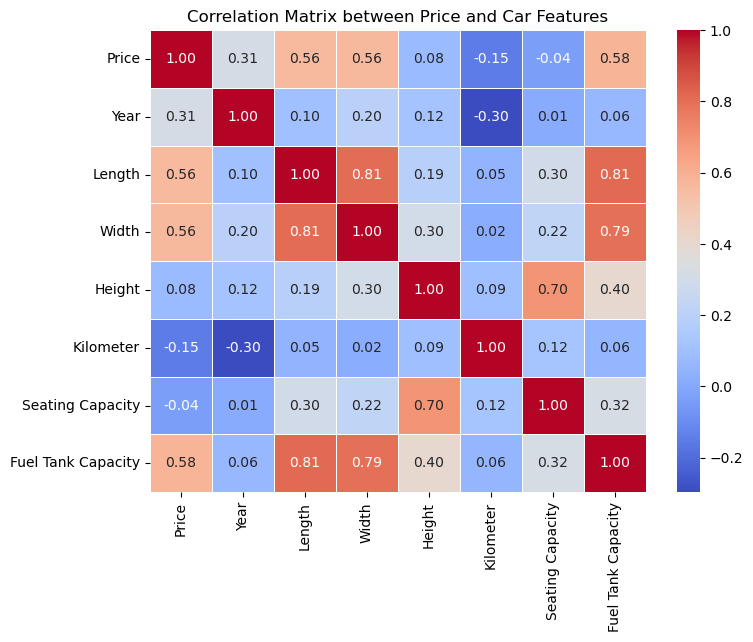

In [21]:
features = ["Price", "Year",  "Length", "Width", "Height"
            ,"Kilometer", "Seating Capacity","Fuel Tank Capacity"]

df_cleaned = Datos.copy()
for col in features:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors="coerce")

corr_matrix = df_cleaned[features].corr()

#print("Correlation Matrix between Price and other features:")
#print(corr_matrix["Price"].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix between Price and Car Features")
plt.show()
#print(corr_matrix)

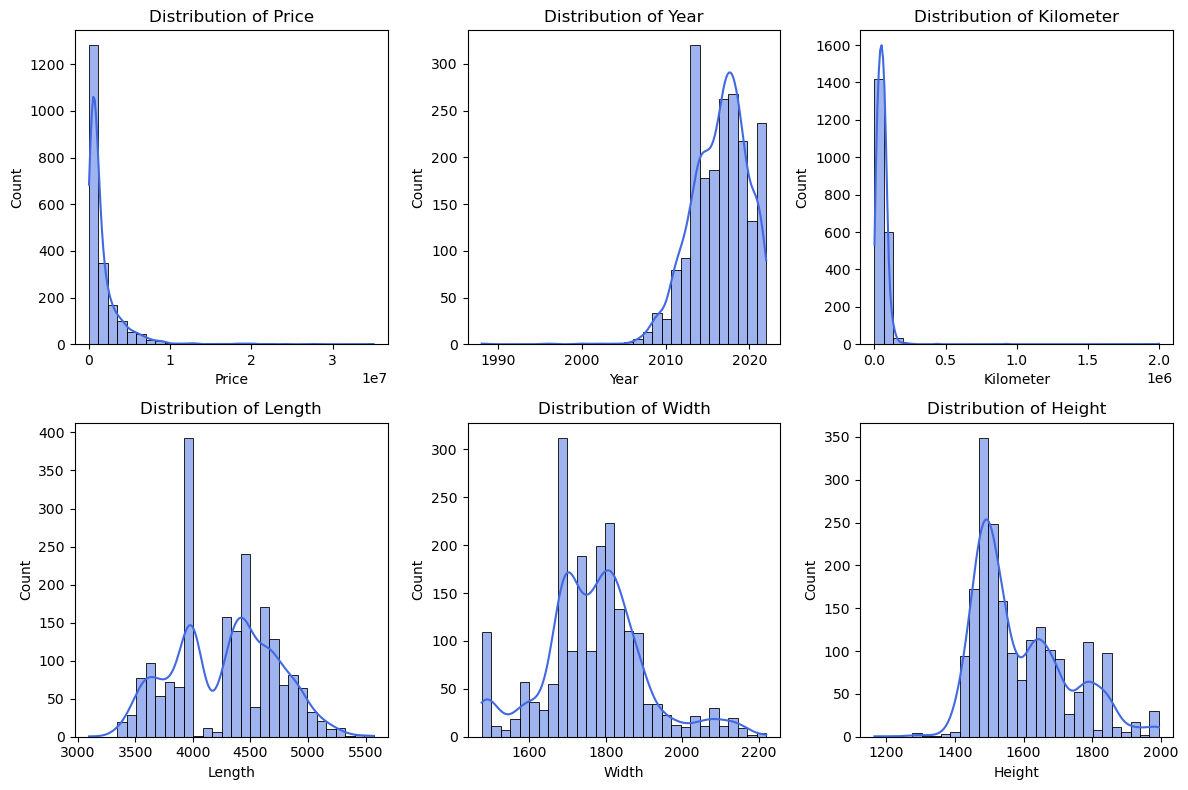

In [24]:
numeric_columns = Datos.select_dtypes(include=["number"]).columns

plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_columns[:6]):  
    plt.subplot(2, 3, i + 1)
    sns.histplot(Datos[col], bins=30, kde=True, color="royalblue")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [32]:
data_transformed = Datos.copy()

data_transformed['Price'] = np.log1p(data_transformed['Price'])  
X = data_transformed.drop(columns=["Price"]) 
y = data_transformed["Price"] 

Característica de interes:

Price : 

In [26]:
# Total de Vinos segun calidad

Datos['Price'].value_counts()

Price
425000     26
625000     24
650000     22
450000     20
375000     20
           ..
1698999     1
3995000     1
9200000     1
426999      1
670000      1
Name: count, Length: 619, dtype: int64

### 4. Dividir el dataset en Train y Test para evaluar correctamente el modelo


In [35]:

cat_features = X.select_dtypes(include=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for col in cat_features:
    X_train[col] = X_train[col].astype(str).fillna("missing")
    X_test[col] = X_test[col].astype(str).fillna("missing")
    
model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, cat_features=cat_features, verbose=100)
model.fit(X_train, y_train)

0:	learn: 0.9465979	total: 191ms	remaining: 3m 10s
100:	learn: 0.2318325	total: 2.98s	remaining: 26.6s
200:	learn: 0.1843321	total: 5.88s	remaining: 23.4s
300:	learn: 0.1581771	total: 8.65s	remaining: 20.1s
400:	learn: 0.1405330	total: 11.6s	remaining: 17.3s
500:	learn: 0.1279564	total: 14.6s	remaining: 14.6s
600:	learn: 0.1177865	total: 17.7s	remaining: 11.7s
700:	learn: 0.1087909	total: 21.3s	remaining: 9.07s
800:	learn: 0.1016313	total: 25s	remaining: 6.21s
900:	learn: 0.0957624	total: 28.6s	remaining: 3.14s
999:	learn: 0.0902248	total: 32s	remaining: 0us


### 5. Entrenar el modelo configurando los diferentes hiperparámetros

In [36]:
y_pred = model.predict(X_test)

y_test_original = np.expm1(y_test)  
y_pred_original = np.expm1(y_pred)

mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test_original, y_pred_original)

### 6. Evaluar el desempeño del modelo en el conjunto de Test con métricas como precisión, recall, F1-score, etc

In [37]:
print(f"📌 Mean Absolute Error (MAE): {mae:.2f}")
print(f"📌 Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"📌 R² Score: {r2:.2f}")

comparison_df = pd.DataFrame({"Actual Price": y_test_original, "Predicted Price": y_pred_original})
print(comparison_df.head(20)) 

📌 Mean Absolute Error (MAE): 288104.97
📌 Root Mean Squared Error (RMSE): 1179742.86
📌 R² Score: 0.80
      Actual Price  Predicted Price
1298     4800000.0     3.782748e+06
591       825000.0     8.345454e+05
1318      695000.0     5.962007e+05
1067      950000.0     8.692738e+05
29        819999.0     7.226176e+05
1058      310000.0     3.726760e+05
712      1000000.0     1.094520e+06
453      1998999.0     2.002950e+06
1646      850000.0     1.315269e+06
757      3950000.0     4.605443e+06
941       545000.0     5.731842e+05
834       685000.0     6.385962e+05
829       949000.0     9.009276e+05
233      9000000.0     5.113211e+06
788       500000.0     4.534506e+05
706       295000.0     2.597335e+05
70        775000.0     7.338815e+05
1121      595000.0     5.874930e+05
128      1875000.0     1.838072e+06
1536      525000.0     4.317456e+05


In [38]:
print("Features used in the model:")
print(X.columns.tolist())  # Print all features used

Features used in the model:
['Make', 'Model', 'Year', 'Kilometer', 'Fuel Type', 'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine', 'Max Power', 'Max Torque', 'Drivetrain', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity']


In [39]:
print("Categorical features used:")
print(cat_features)  # Categorical features used by CatBoost

Categorical features used:
['Make', 'Model', 'Fuel Type', 'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine', 'Max Power', 'Max Torque', 'Drivetrain']


### 7. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo

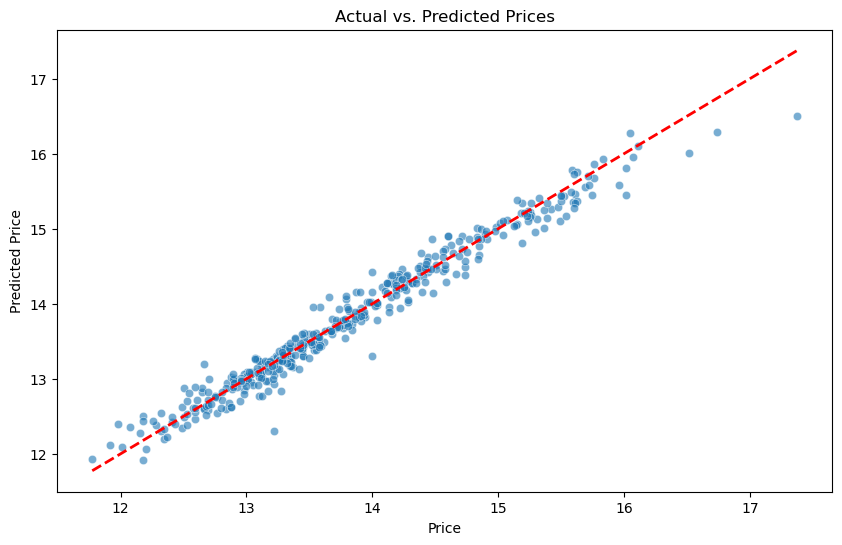

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='dashed', linewidth=2)  
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted Prices")
plt.show()

comparison_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})